# Yhdistäminen

In [21]:
from pymongo import MongoClient
import pandas as pd
import time

client = MongoClient("mongodb://localhost:27017/")
db = client['US-Accidents']
collection = db['accidents']

# Chunkitetaan data ja ladataan sisääm

In [22]:
count = collection.count_documents({})
print(f"Documents in MongoDB: {count}")

if count == 0:
    chunk_size = 10000
    total = 0
    for chunk in pd.read_csv("US_Accidents_March23.csv", chunksize=chunk_size):
        records = chunk.to_dict("records")
        collection.insert_many(records)
        total += len(records)
        print(f"Loaded: {total} rows...")
    print(f"Done! Total {total} documents.")
else:
    print("Data already exists, skipping import!")

Documents in MongoDB: 7728394
Data already exists, skipping import!


## Tarkistetaan sarakkeet

In [23]:
doc = collection.find_one()
keys = list(doc.keys())

chunk_size = 23
columns = [keys[i:i+chunk_size] for i in range(0, len(keys), chunk_size)]

max_len = max(len(col) for col in columns)

for row in range(max_len):
    line = ""
    for col_idx, col in enumerate(columns):
        if row < len(col):
            num = col_idx * chunk_size + row
            line += f"{num:<4}{col[row]:<30}"
    print(line)

0   _id                           23  Humidity(%)                   46  Astronomical_Twilight         
1   ID                            24  Pressure(in)                  
2   Source                        25  Visibility(mi)                
3   Severity                      26  Wind_Direction                
4   Start_Time                    27  Wind_Speed(mph)               
5   End_Time                      28  Precipitation(in)             
6   Start_Lat                     29  Weather_Condition             
7   Start_Lng                     30  Amenity                       
8   End_Lat                       31  Bump                          
9   End_Lng                       32  Crossing                      
10  Distance(mi)                  33  Give_Way                      
11  Description                   34  Junction                      
12  Street                        35  No_Exit                       
13  City                          36  Railway                       


## Tehdään optimointi testi 10 000 datasetillä

In [24]:
import time


start = time.time()
list(collection.find({"State": "CA"}).limit(1000))
embedded_time = time.time() - start
print(f"Embedded query: {embedded_time:.4f}s")


sample = list(collection.find().limit(10000))

accidents_ref = db["accidents_referenced"]
weather_ref = db["weather_referenced"]

accidents_ref.drop()
weather_ref.drop()

for doc in sample:
    weather_id = doc["_id"]
    
    weather_ref.insert_one({
        "weather_id": weather_id,
        "Weather_Condition": doc.get("Weather_Condition"),
        "Temperature(F)": doc.get("Temperature(F)"),
        "Humidity(%)": doc.get("Humidity(%)"),
        "Visibility(mi)": doc.get("Visibility(mi)"),
        "Wind_Speed(mph)": doc.get("Wind_Speed(mph)")
    })
    
    accidents_ref.insert_one({
        "ID": doc.get("ID"),
        "Severity": doc.get("Severity"),
        "State": doc.get("State"),
        "Start_Time": doc.get("Start_Time"),
        "weather_id": weather_id
    })


start = time.time()
accidents = list(accidents_ref.find({"State": "CA"}))
for acc in accidents:
    weather_ref.find_one({"weather_id": acc["weather_id"]})
referenced_time = time.time() - start
print(f"Referenced query: {referenced_time:.4f}s")

print(f"\nEmbedded is {referenced_time/embedded_time:.1f}x faster")

Embedded query: 0.0050s
Referenced query: 12.5849s

Embedded is 2515.7x faster


## Luodaan spark sessio 
### (Remember to change memory size to fit your computer specs)

In [25]:
from pyspark.sql import SparkSession
from pymongo import MongoClient
import pandas as pd

spark = SparkSession.builder \
    .appName("WeatherSeverityAnalysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "20g") \
    .getOrCreate()


client = MongoClient("mongodb://localhost:27017/")
collection = client["US-Accidents"]["accidents"]

print("Documents:", collection.count_documents({}))

# Fetch weather-related columns
cursor = collection.find(
    {},
    {"Severity": 1, "Weather_Condition": 1,
     "Visibility(mi)": 1, "Temperature(F)": 1,
     "Precipitation(in)": 1, "Humidity(%)": 1, "_id": 0}
)

pandas_df = pd.DataFrame(list(cursor))
print("Rows fetched:", len(pandas_df))
print(pandas_df.head(3))

df = spark.createDataFrame(pandas_df)
df.printSchema()
df.show(5)

Documents: 7728394
Rows fetched: 7728394
   Severity  Temperature(F)  Humidity(%)  Visibility(mi)  Precipitation(in)  \
0         3            36.9         91.0            10.0               0.02   
1         2            37.9        100.0            10.0               0.00   
2         2            36.0        100.0            10.0                NaN   

  Weather_Condition  
0        Light Rain  
1        Light Rain  
2          Overcast  
root
 |-- Severity: long (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Visibility(mi): double (nullable = true)
 |-- Precipitation(in): double (nullable = true)
 |-- Weather_Condition: string (nullable = true)

+--------+--------------+-----------+--------------+-----------------+-----------------+
|Severity|Temperature(F)|Humidity(%)|Visibility(mi)|Precipitation(in)|Weather_Condition|
+--------+--------------+-----------+--------------+-----------------+-----------------+
|       3|

## Cachen luominen

In [26]:
# Cachetus
df.cache()
df.count()
print("Cache loaded!")

Cache loaded!


### Luodaan Weather_Group -kategoriasarake

In [27]:
from pyspark.sql.functions import when, col, count, avg, round

df = df.withColumn("Weather_Group",
    when(col("Weather_Condition").contains("Snow") |
         col("Weather_Condition").contains("Sleet") |
         col("Weather_Condition").contains("Ice") |
         col("Weather_Condition").contains("Wintry"), "Snow/Ice")
    .when(col("Weather_Condition").contains("Rain") |
          col("Weather_Condition").contains("Drizzle") |
          col("Weather_Condition").contains("Shower"), "Rain")
    .when(col("Weather_Condition").contains("Thunder") |
          col("Weather_Condition").contains("Storm") |
          col("Weather_Condition").contains("T-Storm") |
          col("Weather_Condition").contains("Tornado"), "Storm")
    .when(col("Weather_Condition").contains("Fog") |
          col("Weather_Condition").contains("Haze") |
          col("Weather_Condition").contains("Mist") |
          col("Weather_Condition").contains("Smoke") |
          col("Weather_Condition").contains("Dust") |
          col("Weather_Condition").contains("Sand") |
          col("Weather_Condition").contains("Volcanic Ash"), "Low Visibility")
    .when(col("Weather_Condition").contains("Cloud") |
          col("Weather_Condition").contains("Overcast"), "Cloudy")
    .when(col("Weather_Condition").contains("Clear") |
          col("Weather_Condition").contains("Fair"), "Fair/Clear")
    .when(col("Weather_Condition").contains("Wind") |
          col("Weather_Condition").contains("Breezy") |
          col("Weather_Condition").contains("Squall"), "Windy")
    .when(col("Weather_Condition").contains("Hail"), "Hail")
    .when(col("Weather_Condition").isNull() | (col("Weather_Condition") == "nan") |
          (col("Weather_Condition") == "N/A Precipitation"), "Unknown")
    .otherwise("Other")
)

df.groupBy("Weather_Group") \
    .agg(count("*").alias("accidents"),
         round(avg("Severity"), 2).alias("avg_severity")) \
    .orderBy("accidents", ascending=False) \
    .show()

+--------------+---------+------------+
| Weather_Group|accidents|avg_severity|
+--------------+---------+------------+
|    Fair/Clear|  3405216|        2.18|
|        Cloudy|  3163750|        2.23|
|          Rain|   540375|        2.25|
|Low Visibility|   203168|        2.18|
|       Unknown|   176711|        2.25|
|      Snow/Ice|   173727|        2.23|
|         Storm|    65248|        2.19|
|          Hail|      117|        2.25|
|         Windy|       82|        2.27|
+--------------+---------+------------+



### Check if there is still category to add on Weather_Groups

In [28]:
df.filter(col("Weather_Group") == "Other") \
    .groupBy("Weather_Condition") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()


+-----------------+-----+
|Weather_Condition|count|
+-----------------+-----+
+-----------------+-----+



### Tallennetaan tulokset Mongoon (removes collection before adding another to avoid duplicates)

In [29]:
weather_group_results = df.groupBy("Weather_Group") \
    .agg(count("*").alias("accidents"),
         round(avg("Severity"), 2).alias("avg_severity")) \
    .orderBy("accidents", ascending=False) \
    .toPandas().to_dict("records")

db["weather_group_results"].drop()
db["weather_group_results"].insert_many(weather_group_results)
print(f"{len(weather_group_results)} Weather_Group tulosta tallennettu MongoDB:hen")

9 Weather_Group tulosta tallennettu MongoDB:hen


### Onnettomuuksien määrä vakavuuden keskiarvon mukaan

In [30]:
from pyspark.sql.functions import count, avg, round

df.groupBy("Weather_Group") \
    .agg(count("*").alias("accidents"),
         round(avg("Severity"), 2).alias("avg_severity")) \
    .orderBy("accidents", ascending=False) \
    .show()


+--------------+---------+------------+
| Weather_Group|accidents|avg_severity|
+--------------+---------+------------+
|    Fair/Clear|  3405216|        2.18|
|        Cloudy|  3163750|        2.23|
|          Rain|   540375|        2.25|
|Low Visibility|   203168|        2.18|
|       Unknown|   176711|        2.25|
|      Snow/Ice|   173727|        2.23|
|         Storm|    65248|        2.19|
|          Hail|      117|        2.25|
|         Windy|       82|        2.27|
+--------------+---------+------------+



### Tarkistetaan vakavuusluokkien määriä

In [31]:
severe = df.filter(df["Severity"] >= 3).count()
minor = df.filter(df["Severity"] < 3).count()
print(f"Severe (3-4): {severe}")
print(f"Minor (1-2): {minor}")

Severe (3-4): 1504047
Minor (1-2): 6224347


### Näkyvyys onnettomuushetkellä

In [32]:
df.createOrReplaceTempView("weather_accidents")
spark.sql("""
    SELECT 
        CASE 
            WHEN `Visibility(mi)` < 1 THEN 'Under 1 mile'
            WHEN `Visibility(mi)` < 5 THEN '1-5 miles'
            ELSE 'Over 5 miles'
        END as visibility,
        COUNT(*) as accidents,
        ROUND(AVG(Severity), 2) as avg_severity
    FROM weather_accidents
    GROUP BY visibility
    ORDER BY avg_severity DESC
""").show()

+------------+---------+------------+
|  visibility|accidents|avg_severity|
+------------+---------+------------+
|   1-5 miles|   506793|        2.23|
|Under 1 mile|   117131|        2.21|
|Over 5 miles|  7104470|        2.21|
+------------+---------+------------+



### Lämpötila onnettomuushetkellä

In [33]:
spark.sql("""
    SELECT 
        CASE 
            WHEN `Temperature(F)` < 32 THEN 'Freezing (below 32F)'
            WHEN `Temperature(F)` < 60 THEN 'Cool (32-60F)'
            ELSE 'Warm (above 60F)'
        END as temperature,
        COUNT(*) as accidents,
        ROUND(AVG(Severity), 2) as avg_severity
    FROM weather_accidents
    GROUP BY temperature
    ORDER BY accidents DESC
""").show()

+--------------------+---------+------------+
|         temperature|accidents|avg_severity|
+--------------------+---------+------------+
|    Warm (above 60F)|  4549070|        2.21|
|       Cool (32-60F)|  2636084|        2.21|
|Freezing (below 32F)|   543240|        2.24|
+--------------------+---------+------------+



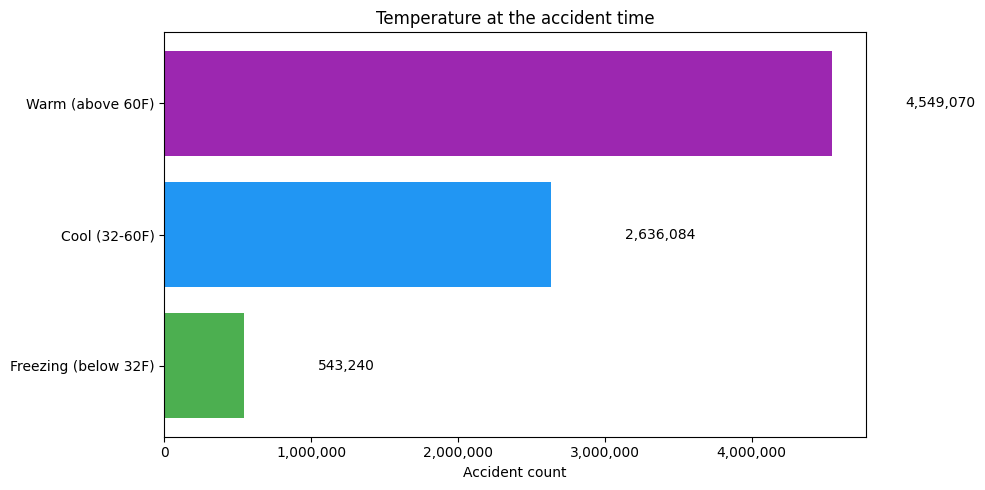

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "temperature": ["Warm (above 60F)", "Cool (32-60F)", "Freezing (below 32F)"],
    "accidents": [4549070, 2636084, 543240]
}

temp_df = pd.DataFrame(data)
temp_df = temp_df.sort_values("accidents")

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(temp_df["temperature"], temp_df["accidents"], color=["#4CAF50", "#2196F3", "#9C27B0"])

for bar in bars:
    width = bar.get_width()
    ax.text(width + 500000, bar.get_y() + bar.get_height() / 2,
            f"{width:,}", va="center", fontsize=10)

ax.set_xlabel("Accident count")
ax.set_title("Temperature at the accident time")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

### Ristianalyysi lämmön ja sääolosuhgteen mukaan

In [35]:
cross_analysis_pd = spark.sql("""
    SELECT
        Weather_Group,
        CASE
            WHEN `Temperature(F)` < 32 THEN 'Freezing'
            WHEN `Temperature(F)` < 60 THEN 'Cool'
            ELSE 'Warm'
        END as temperature,
        COUNT(*) as accidents,
        ROUND(AVG(Severity), 2) as avg_severity
    FROM weather_accidents
    WHERE Weather_Group IN ('Cloudy', 'Low Visibility', 'Unknown', 'Snow/Ice', 'Storm', 'Hail', 'Windy', 'Rain', 'Fair/Clear')
    GROUP BY Weather_Group, temperature
    ORDER BY accidents DESC
""").toPandas()

print(cross_analysis_pd)

     Weather_Group temperature  accidents  avg_severity
0       Fair/Clear        Warm    2126283          2.18
1           Cloudy        Warm    1885251          2.23
2           Cloudy        Cool    1086697          2.23
3       Fair/Clear        Cool    1085046          2.18
4             Rain        Cool     306031          2.25
5             Rain        Warm     229804          2.26
6       Fair/Clear    Freezing     193887          2.23
7           Cloudy    Freezing     191802          2.26
8          Unknown        Warm     155594          2.24
9         Snow/Ice    Freezing     131134          2.24
10  Low Visibility        Cool      96666          2.16
11  Low Visibility        Warm      90614          2.21
12           Storm        Warm      61011          2.19
13        Snow/Ice        Cool      42143          2.22
14  Low Visibility    Freezing      15888          2.18
15         Unknown        Cool      15224          2.34
16         Unknown    Freezing       5893       

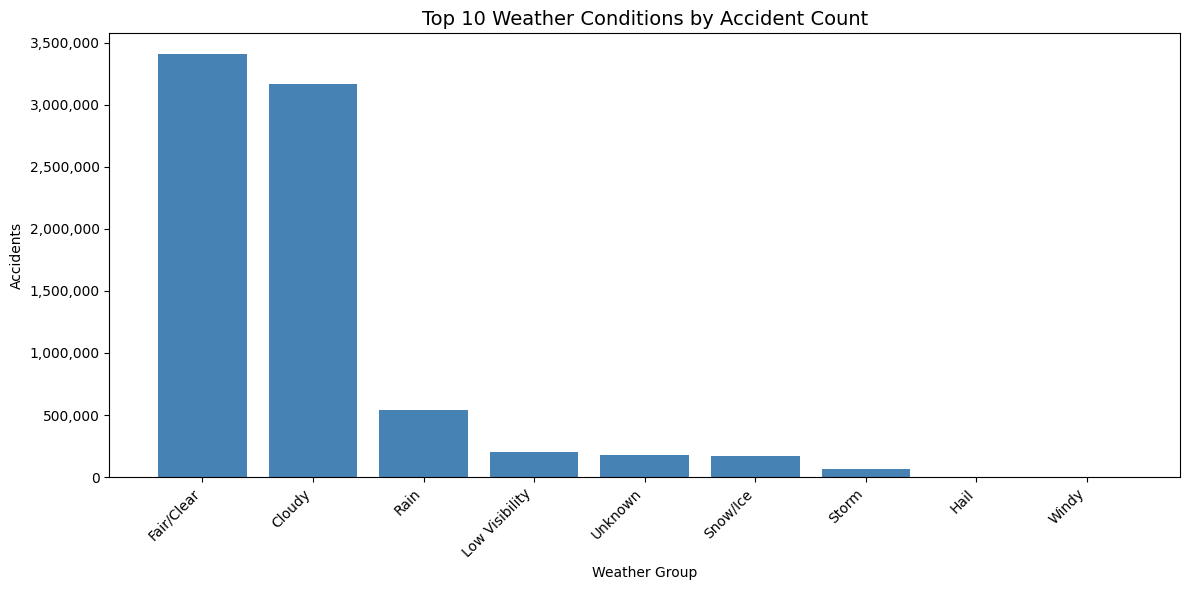

In [37]:
weather_pd = df.groupBy("Weather_Group") \
    .agg(count("*").alias("accidents"),
         round(avg("Severity"), 2).alias("avg_severity")) \
    .orderBy("accidents", ascending=False) \
    .limit(10) \
    .toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(weather_pd["Weather_Group"], 
              weather_pd["accidents"],
              color="steelblue")
ax.set_title("Top 10 Weather Conditions by Accident Count", fontsize=14)
ax.set_xlabel("Weather Group")
ax.set_ylabel("Accidents")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("weather_accidents.png", dpi=150)
plt.show()

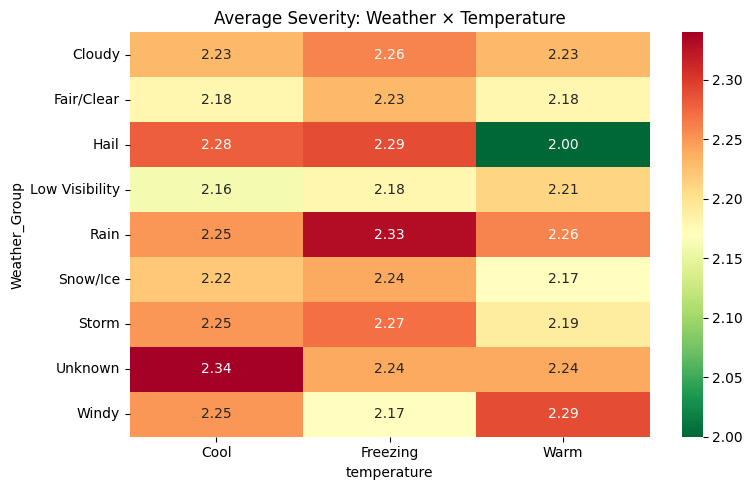

In [38]:
import seaborn as sns

pivot = cross_analysis_pd.pivot(index="Weather_Group",
                                columns="temperature",
                                values="avg_severity")


fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=ax)
ax.set_title("Average Severity: Weather × Temperature")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()